In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
import cartopy.crs as ccrs
import cartopy.feature as cfeature



pa_gs = pd.read_csv('data/pa_data.csv')
pa_gs_no_ohc = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico','sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']

In [2]:
pa_gs_dropna_test = pa_gs[['year', 'latitude', 'longitude', 'growing_season_length']].dropna()
lon = pa_gs_dropna_test['longitude']
lat = pa_gs_dropna_test['latitude']
var = pa_gs_dropna_test['growing_season_length']

In [3]:
OK = OrdinaryKriging(x=lon, y=lat, z=var, variogram_model='exponential', coordinates_type='geographic')
grid_lat = np.arange(min(lat), max(lat), 0.3)
grid_lon = np.arange(min(lon), max(lon), 0.3)
zstar, ss = OK.execute('grid', grid_lon, grid_lat)

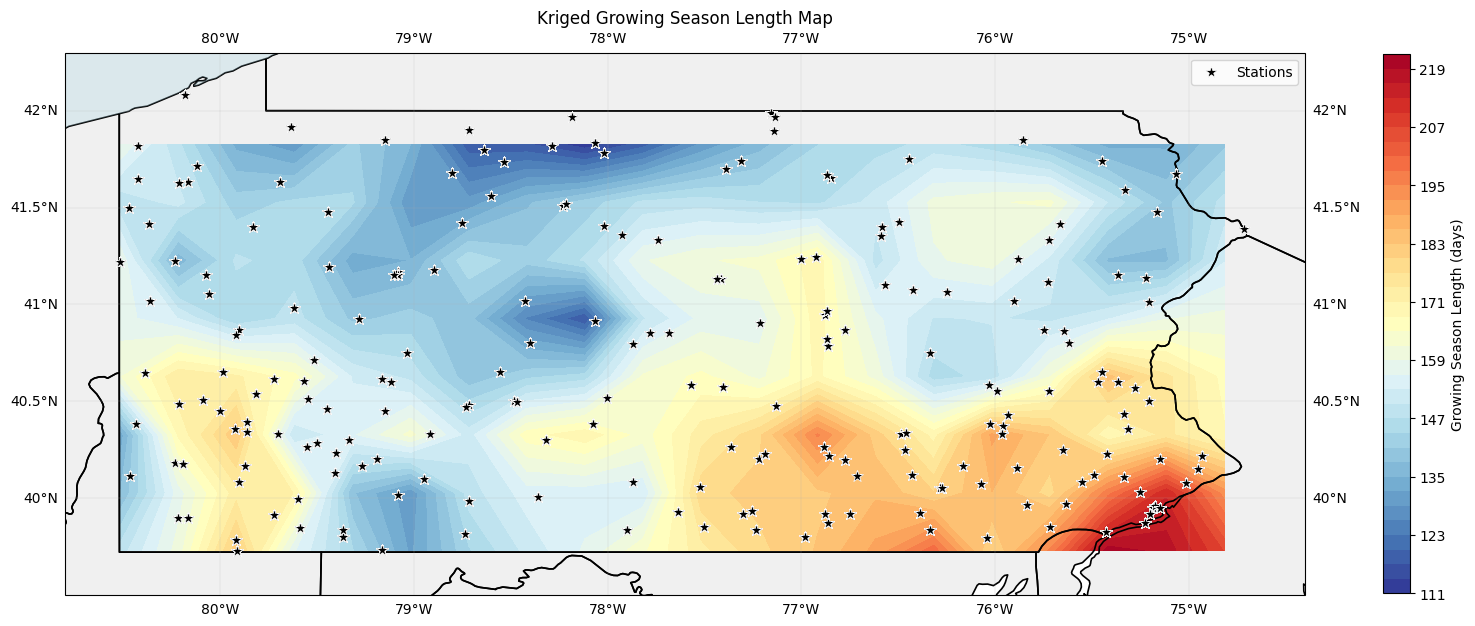

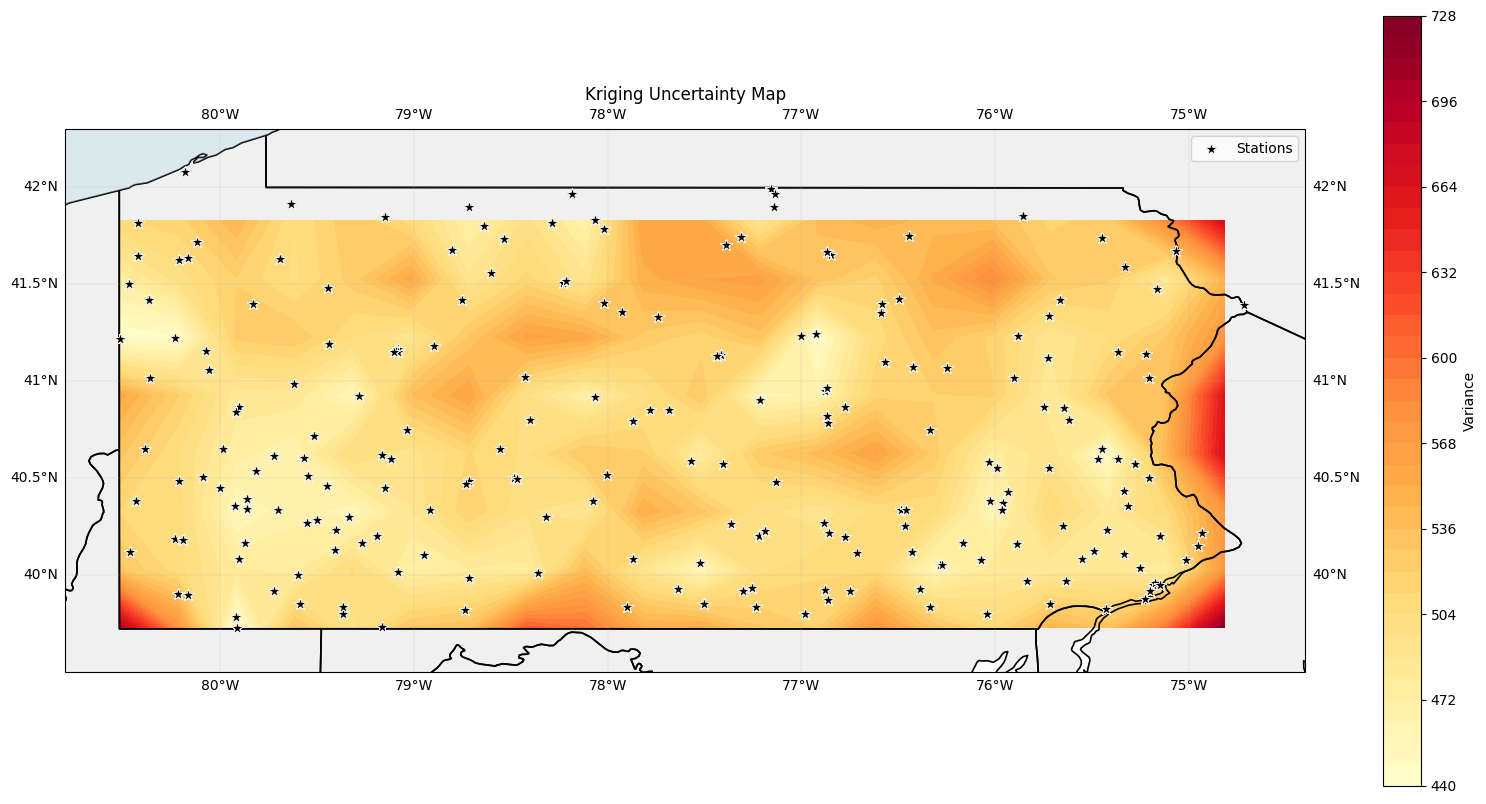

In [4]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon, grid_lat, zstar, levels=40 , cmap='RdYlBu_r')
plt.colorbar(label='Growing Season Length (days)', shrink = 0.7)
plt.scatter(lon, lat, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriged Growing Season Length Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()


plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon, grid_lat, ss, levels=40 , cmap='YlOrRd')
plt.colorbar(label='Variance')
plt.scatter(lon, lat, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriging Uncertainty Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()

In [5]:
def difference_finder(dataset, start_yr, end_yr, variable):
    data_start = dataset[dataset['year'] == start_yr]
    data_end = dataset[dataset['year'] == end_yr]
    new_df = pd.concat([data_start, data_end], ignore_index=True)
    new_df = new_df[['year', 'station_name', 'latitude', 'longitude', variable]].dropna()
    
    final_df = pd.DataFrame()
    for station in new_df['station_name'].unique():  # iterate over unique stations
        station_df = new_df[new_df['station_name'] == station]
        
        start_row = station_df[station_df['year'] == start_yr]
        end_row = station_df[station_df['year'] == end_yr]
        
        # Only calculate if both years exist for this station
        if len(start_row) > 0 and len(end_row) > 0:
            start_val = start_row[variable].values[0]
            end_val = end_row[variable].values[0]
            change = end_val - start_val
            lat = start_row['latitude'].values[0]
            lon = start_row['longitude'].values[0]
            final_df = pd.concat([final_df, pd.DataFrame({
                'station_name': [station],
                'latitude': [lat],
                'longitude': [lon],
                'change': [change]
            })], ignore_index=True)
    
    return(final_df)

pa_gs_diff = difference_finder(pa_gs, 1975, 2020, 'growing_season_length')
print(pa_gs_diff)

                     station_name  latitude  longitude  change
0                     ALTOONA 3 W   40.4950   -78.4667     -26
1                     BIGLERVILLE   39.9347   -77.2547      11
2             BRADFORD 4SW RSCH 5   41.8981   -78.7144     -17
3              CHAMBERSBURG 1 ESE   39.9283   -77.6372     -32
4             CONFLUENCE 1 SW DAM   39.7994   -79.3664      -2
5                    DONEGAL 2 NW   40.1275   -79.4058     -24
6            EBENSBURG SEWAGE PLT   40.4681   -78.7308      -1
7                         EVERETT   40.0086   -78.3586     -62
8               FORD CITY 4 S DAM   40.7150   -79.5133      -3
9            FRANCIS E WALTER DAM   41.1183   -75.7278      -7
10                       FRANKLIN   41.4003   -79.8306     -12
11                   INDIANA 3 SE   40.5972   -79.1186      -3
12                 JAMESTOWN 2 NW   41.4992   -80.4681      21
13                      KANE 1NNE   41.6769   -78.8036       1
14               LANDISVILLE 2 NW   40.1192   -76.4264 

In [6]:
lon_diff = pa_gs_diff['longitude']
lat_diff = pa_gs_diff['latitude']
var_diff = pa_gs_diff['change']

ax.clear()

OK_diff = OrdinaryKriging(x=lon_diff, y=lat_diff, z=var_diff, variogram_model='exponential', coordinates_type='geographic')
grid_lat_diff = np.arange(min(lat_diff), max(lat_diff), 0.3)
grid_lon_diff = np.arange(min(lon_diff), max(lon_diff), 0.3)
zstar_diff, ss_diff = OK_diff.execute('grid', grid_lon_diff, grid_lat_diff)

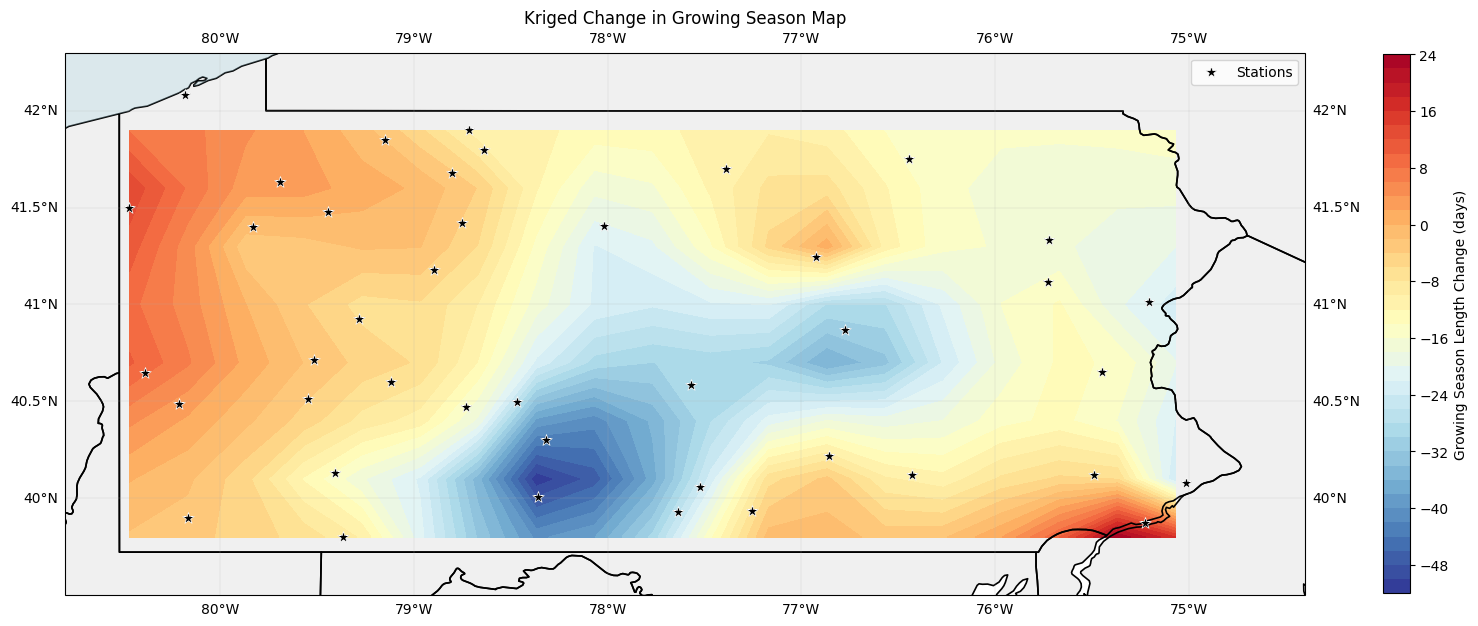

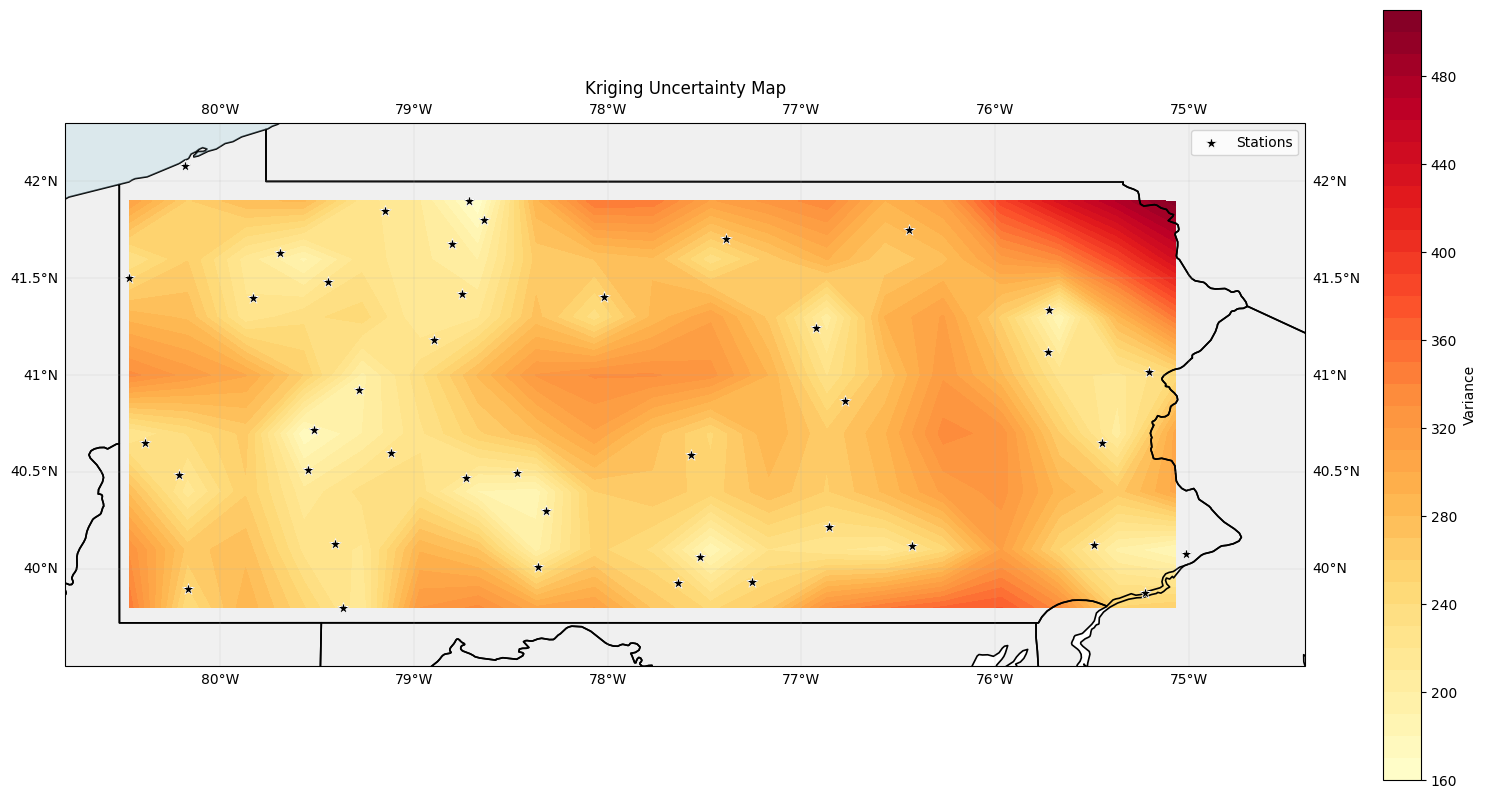

In [7]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon_diff, grid_lat_diff, zstar_diff, levels=40 , cmap='RdYlBu_r')
plt.colorbar(label='Growing Season Length Change (days)', shrink = 0.7)
plt.scatter(lon_diff, lat_diff, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriged Change in Growing Season Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon_diff, grid_lat_diff, ss_diff, levels=40 , cmap='YlOrRd')
plt.colorbar(label='Variance')
plt.scatter(lon_diff, lat_diff, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriging Uncertainty Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()

In [8]:
#find the five year means at each station before an inputted beginning and end date
starting_mean = pa_gs[pa_gs['year'].between(1945, 1950)]
ending_mean = pa_gs[pa_gs['year'].between(2020, 2025)]

starting_mean = starting_mean[['year', 'latitude', 'longitude', 'station_name', 'growing_season_length']]
ending_mean = ending_mean[['year', 'latitude', 'longitude', 'station_name', 'growing_season_length']]

starting_mean = starting_mean.groupby('station_name').agg(['mean'])
ending_mean = ending_mean.groupby('station_name').agg(['mean'])

starting_mean.columns = ['_'.join(col).strip() for col in starting_mean.columns.values]
ending_mean.columns = ['_'.join(col).strip() for col in ending_mean.columns.values]

starting_mean = starting_mean.reset_index()
starting_mean.columns = ['station_name', 'year', 'latitude', 'longitude', 'growing_season_length']
ending_mean = ending_mean.reset_index()
ending_mean.columns = ['station_name', 'year', 'latitude', 'longitude', 'growing_season_length']

#take those two five year means and find the difference between them at each station

new_df_diff_mean = pd.concat([starting_mean, ending_mean], ignore_index=True)
new_df_diff_mean = new_df_diff_mean[['year', 'station_name', 'latitude', 'longitude', 'growing_season_length']].dropna()

final_df_diff_mean = pd.DataFrame()
for station in new_df_diff_mean['station_name'].unique():  # iterate over unique stations
    station_df = new_df_diff_mean[new_df_diff_mean['station_name'] == station]
        
    start_row = station_df[station_df['year'].between(1945, 1950)]
    end_row = station_df[station_df['year'].between(2020,2025)]
        
    # Only calculate if both years exist for this station
    if len(start_row) > 0 and len(end_row) > 0:
        start_val = start_row['growing_season_length'].values[0]
        end_val = end_row['growing_season_length'].values[0]
        change = end_val - start_val
        lat = start_row['latitude'].values[0]
        lon = start_row['longitude'].values[0]
        final_df_diff_mean = pd.concat([final_df_diff_mean, pd.DataFrame({
            'station_name': [station],
            'latitude': [lat],
            'longitude': [lon],
            'change': [change]
        })], ignore_index=True)

#run Kriging on that dataframe and output two plots

lon_diff_mean = final_df_diff_mean['longitude']
lat_diff_mean = final_df_diff_mean['latitude']
var_diff_mean = final_df_diff_mean['change']

ax.clear()

OK_diff_mean = OrdinaryKriging(x=lon_diff_mean, y=lat_diff_mean, z=var_diff_mean, variogram_model='exponential', coordinates_type='geographic')
grid_lat_diff_mean = np.arange(min(lat_diff_mean), max(lat_diff_mean), 0.3)
grid_lon_diff_mean = np.arange(min(lon_diff_mean), max(lon_diff_mean), 0.3)
zstar_diff_mean, ss_diff_mean = OK_diff_mean.execute('grid', grid_lon_diff_mean, grid_lat_diff_mean)

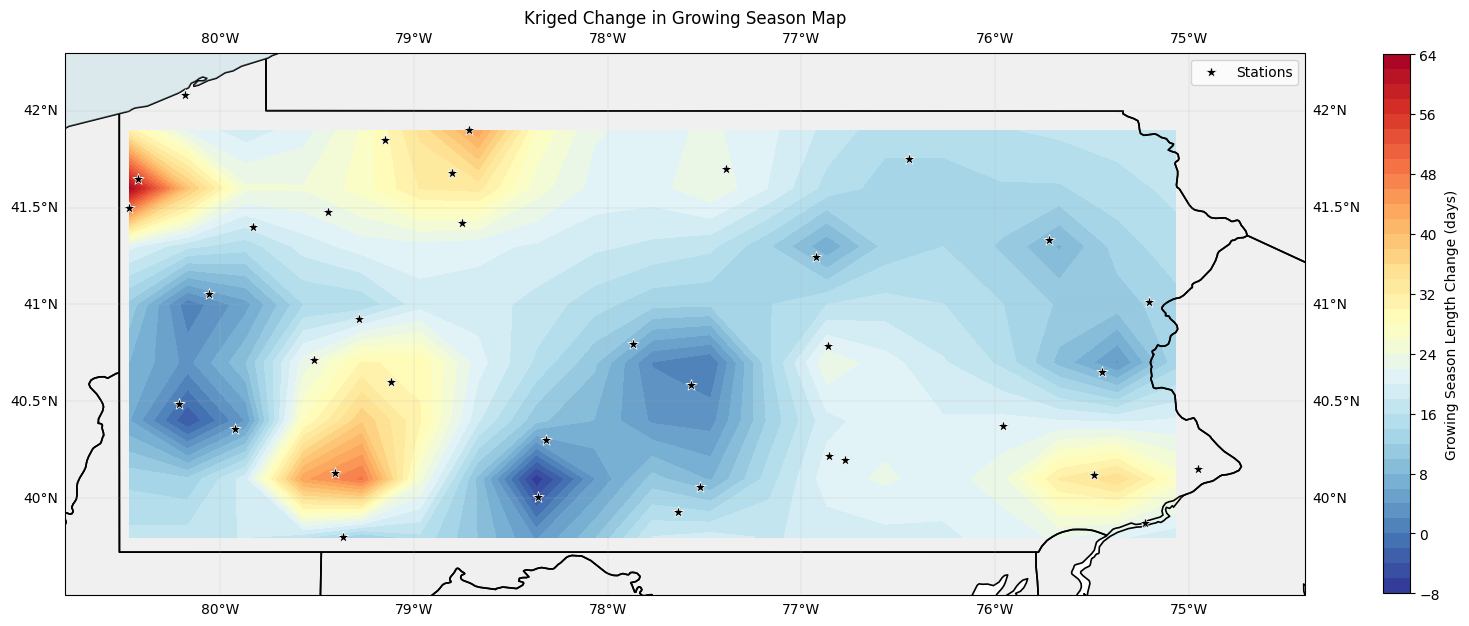

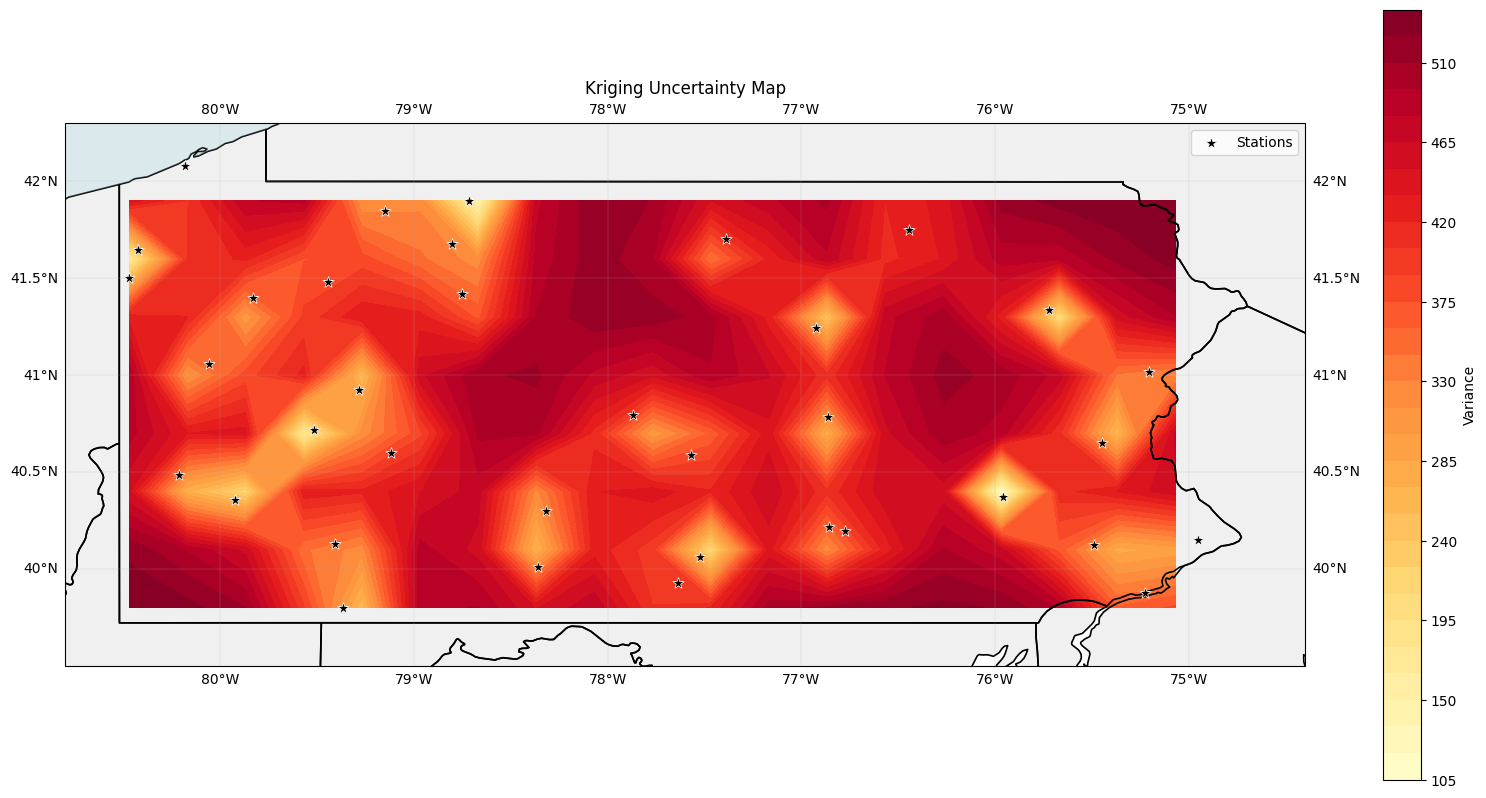

In [9]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon_diff_mean, grid_lat_diff_mean, zstar_diff_mean, levels=40 , cmap='RdYlBu_r')
plt.colorbar(label='Growing Season Length Change (days)', shrink = 0.7)
plt.scatter(lon_diff_mean, lat_diff_mean, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriged Change in Growing Season Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon_diff_mean, grid_lat_diff_mean, ss_diff_mean, levels=40 , cmap='YlOrRd')
plt.colorbar(label='Variance')
plt.scatter(lon_diff_mean, lat_diff_mean, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriging Uncertainty Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()